# Bitcoin Forecast Freeze and Validation

## Role
This notebook formally certifies the Bitcoin forecast evidence after model generation is complete.

> This notebook is the boundary between expensive forecast generation and downstream artifact-only analysis.

## Inputs
The authoritative forecast matrix `results/validated_forecasts.csv` and supporting frozen artifacts referenced by the repository-level verifier.

## Outputs
This notebook produces validation evidence, the canonical 10-model performance ranking, a relative-performance summary, and artifact-integrity confirmation. It does **not** create new forecasts.

## Depends On
Notebooks 02-06, because those notebooks produce or document the frozen forecast vectors certified here.

## Authoritative Status
`AUTHORITATIVE FORECAST FREEZE / VALIDATION GATE`

## What This Notebook Does Not Do
No model training. No checkpoint loading. No forecast regeneration. No uncertainty synthesis. No robustness analysis. No statistical significance testing. No Trust Score calculation.

# 1. Objective and Research Question

> Can the completed Bitcoin forecast vectors be certified as one internally consistent, aligned, immutable evidence set suitable for all downstream evaluation?

> **The full 10-model ranking produced in this notebook is the authoritative Bitcoin point-forecast ranking. Any narrower model comparison shown elsewhere in the repository is a subset of this table and must remain numerically and narratively consistent with it.**

This guards against stale subset rankings, contradictory manuscript claims, accidental model omission, timestamp misalignment, silent join errors, stale figures, and stale documentation.

## Single Source of Truth

> `results/validated_forecasts.csv` is the authoritative Bitcoin point-forecast matrix, while the full ranking generated in this notebook is the authoritative point-forecast performance summary.

Any downstream README table, manuscript result table, proposal preliminary result, figure, or case-study statement must be generated from, or checked against, this source.

# 2. Setup

Standard project-root discovery. Only the repository's existing Bitcoin pipeline utilities (pandas/NumPy-based validation and metric helpers) are loaded -- no model-training library is imported anywhere in this notebook.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.bitcoin_pipeline import *

RUN_GENERATION = False
PROMOTE_TO_AUTHORITATIVE = False

# 3. Data and Method

## 3.1 Freeze Boundary Definition

A forecast vector is **frozen** when: model generation has completed; target timestamps are fixed; forecast values are saved to a versioned CSV; downstream analysis reads these saved values without recomputation; an authoritative SHA-256 hash protects the evidence (`results/authoritative_artifact_hashes.md`); and later analysis cannot silently modify the original forecast vector without that change being detectable.

Downstream notebooks (robustness, temporal stability, uncertainty synthesis, statistical significance, Trust Scores) should derive their evidence from these frozen artifacts rather than rerunning any model.

## 3.2 Authoritative Forecast Matrix

`results/validated_forecasts.csv` is the canonical matrix: `Timestamp` plus `Actual` plus 9 saved model forecast columns (11 columns on disk; 10 non-Timestamp columns once `Timestamp` becomes the index). The 10th analytical model, **7-Day Moving Average**, is not stored -- it is reconstructed deterministically downstream from the frozen `Actual` history via `src.bitcoin_pipeline.seven_day_moving_average`. Artifact column names are used exactly as stored; display names are applied only for presentation, never by renaming the underlying artifact.

In [2]:
schema_table = pd.DataFrame([
    {'Field / Model': 'Timestamp', 'Stored in validated_forecasts.csv?': 'Yes', 'Artifact column': 'Timestamp (index)', 'Source / Reconstruction': 'Canonical test index'},
    {'Field / Model': 'Actual', 'Stored in validated_forecasts.csv?': 'Yes', 'Artifact column': 'Actual', 'Source / Reconstruction': 'Frozen target'},
    {'Field / Model': 'Naive', 'Stored in validated_forecasts.csv?': 'Yes', 'Artifact column': 'Naive', 'Source / Reconstruction': 'Frozen forecast column'},
    {'Field / Model': 'Simple Exponential Smoothing', 'Stored in validated_forecasts.csv?': 'Yes', 'Artifact column': 'Simple_Exp_Smoothing', 'Source / Reconstruction': 'Frozen forecast column'},
    {'Field / Model': 'Additive-Trend Exponential Smoothing', 'Stored in validated_forecasts.csv?': 'Yes', 'Artifact column': 'Holt_Winters', 'Source / Reconstruction': 'Frozen forecast column (historical artifact column name retained)'},
    {'Field / Model': 'ARIMA Rolling One-Step', 'Stored in validated_forecasts.csv?': 'Yes', 'Artifact column': 'ARIMA_Rolling', 'Source / Reconstruction': 'Frozen forecast column'},
    {'Field / Model': 'Prophet — 30-Day Periodic Refit', 'Stored in validated_forecasts.csv?': 'Yes', 'Artifact column': 'Prophet_Periodic_Refit', 'Source / Reconstruction': 'Frozen forecast column'},
    {'Field / Model': 'Persistence-Enhanced Log-Return LSTM', 'Stored in validated_forecasts.csv?': 'Yes', 'Artifact column': 'Persistence_Enhanced_LSTM', 'Source / Reconstruction': 'Frozen forecast column'},
    {'Field / Model': 'Persistence-Enhanced Log-Return Transformer', 'Stored in validated_forecasts.csv?': 'Yes', 'Artifact column': 'Persistence_Enhanced_Transformer', 'Source / Reconstruction': 'Frozen forecast column'},
    {'Field / Model': 'Chronos-Bolt-Tiny', 'Stored in validated_forecasts.csv?': 'Yes', 'Artifact column': 'Chronos_Bolt_Tiny', 'Source / Reconstruction': 'Frozen forecast column'},
    {'Field / Model': 'TimesFM', 'Stored in validated_forecasts.csv?': 'Yes', 'Artifact column': 'TimesFM', 'Source / Reconstruction': 'Frozen forecast column'},
    {'Field / Model': '7-Day Moving Average', 'Stored in validated_forecasts.csv?': 'No / reconstructed', 'Artifact column': 'N/A', 'Source / Reconstruction': 'Deterministic from frozen Actual history: target.shift(1).rolling(7).mean()'},
]).set_index('Field / Model')
schema_table

,Stored in validated_forecasts.csv?,Artifact column,Source / Reconstruction
Field / Model,,,
Timestamp,Yes,Timestamp (index),Canonical test index
Actual,Yes,Actual,Frozen target
Naive,Yes,Naive,Frozen forecast column
Simple Exponential Smoothing,Yes,Simple_Exp_Smoothing,Frozen forecast column
Additive-Trend Exponential Smoothing,Yes,Holt_Winters,Frozen forecast column (historical artifact co...
ARIMA Rolling One-Step,Yes,ARIMA_Rolling,Frozen forecast column
Prophet — 30-Day Periodic Refit,Yes,Prophet_Periodic_Refit,Frozen forecast column
Persistence-Enhanced Log-Return LSTM,Yes,Persistence_Enhanced_LSTM,Frozen forecast column
Persistence-Enhanced Log-Return Transformer,Yes,Persistence_Enhanced_Transformer,Frozen forecast column


## 3.3 Integrity Criteria and Failure Meaning

Before running any validation table, each check's purpose and failure meaning is stated explicitly.

In [3]:
integrity_meaning = pd.DataFrame([
    {'Integrity Check': 'Schema / expected shape', 'Why It Matters': 'Ensures all expected evidence is present', 'What Failure Would Indicate': 'Missing/extra model vector or stale artifact'},
    {'Integrity Check': 'Exact timestamp alignment', 'Why It Matters': 'Ensures every forecast refers to the same target date', 'What Failure Would Indicate': 'Broken join, shifted forecast, possible silent evaluation error'},
    {'Integrity Check': 'Actual-value identity', 'Why It Matters': 'Ensures every model is evaluated against the same target vector', 'What Failure Would Indicate': 'Inconsistent preprocessing or target mismatch'},
    {'Integrity Check': 'Finiteness / completeness', 'Why It Matters': 'Prevents hidden NaN/Inf contamination', 'What Failure Would Indicate': 'Failed generation or corrupted artifact'},
    {'Integrity Check': 'Chronological ordering / uniqueness', 'Why It Matters': 'Ensures deterministic time-series evaluation', 'What Failure Would Indicate': 'Duplicate timestamps, ordering bug, invalid temporal comparison'},
]).set_index('Integrity Check')
integrity_meaning

,Why It Matters,What Failure Would Indicate
Integrity Check,,
Schema / expected shape,Ensures all expected evidence is present,Missing/extra model vector or stale artifact
Exact timestamp alignment,Ensures every forecast refers to the same targ...,"Broken join, shifted forecast, possible silent..."
Actual-value identity,Ensures every model is evaluated against the s...,Inconsistent preprocessing or target mismatch
Finiteness / completeness,Prevents hidden NaN/Inf contamination,Failed generation or corrupted artifact
Chronological ordering / uniqueness,Ensures deterministic time-series evaluation,"Duplicate timestamps, ordering bug, invalid te..."


Also checked below: row count, exact test period, and duplicate-timestamp status. Timestamp misalignment does not automatically prove leakage, but it can produce invalid comparisons and can mask a target/forecast shift.

# 4. Validation Results

## 4.1 Freeze Integrity Checks

> The checks below certify the frozen matrix itself before any metric ranking is accepted.

These checks establish internal consistency, not complete model-level leakage freedom (see Limitations, Section 8).

In [4]:
# Load the canonical split and frozen forecast matrix.
_, target = load_bitcoin_target(ROOT)
train, test = canonical_split(target)
validated = load_validated_forecasts(ROOT)

checks = {
    'Expected row count (1,061)': len(validated) == 1061,
    'Expected schema (1,061 rows x 10 data columns)': validated.shape == (1061, 10),
    'Exact timestamp alignment to canonical test index': validated.index.equals(test.index),
    'Timestamp uniqueness': validated.index.is_unique,
    'Chronological ordering': validated.index.is_monotonic_increasing,
    'Actual-value identity vs canonical target': np.allclose(validated.Actual, test),
    'Finite Actual values': np.isfinite(validated.Actual.to_numpy()).all(),
    'Finite forecast vectors (all columns)': np.isfinite(validated.to_numpy()).all(),
    'Full target coverage (no missing test dates)': validated.index.equals(test.index) and len(validated) == len(test),
    'No duplicate forecast rows': not validated.index.duplicated().any(),
    'Exact test period (2023-08-12 to 2026-07-07)': (validated.index.min() == test.index.min()) and (validated.index.max() == test.index.max()),
}
assert all(checks.values())

pd.Series(checks, name='Passed').to_frame()

,Passed
"Expected row count (1,061)",True
"Expected schema (1,061 rows x 10 data columns)",True
Exact timestamp alignment to canonical test index,True
Timestamp uniqueness,True
Chronological ordering,True
Actual-value identity vs canonical target,True
Finite Actual values,True
Finite forecast vectors (all columns),True
Full target coverage (no missing test dates),True
No duplicate forecast rows,True


## 4.2 External Artifact Verifier

The inline checks above validate the canonical Bitcoin forecast matrix. The repository-level verifier (`src/verify_research_artifacts.py`, inspected read-only) performs a broader, independent regression audit: it checks all 52 SHA-256-protected artifacts in `results/authoritative_artifact_hashes.md`, schema/row-count/key/timestamp validity for `validated_forecasts.csv` and both Electricity protocol files, several individual Bitcoin point-forecast vectors, the rebuilt Bitcoin evidence artifacts, and that the cross-domain synthesis CSVs load successfully. It is a broader independent audit over protected artifacts, schemas, row counts, hashes, and metrics -- not limited to this one matrix.

> The verifier's total PASS count is not a scientific result and should not be treated as a fixed repository statistic. It can increase when new legitimate checks are added. The meaningful condition is zero failed checks, not preservation of a historical PASS total.

In [5]:
import subprocess

run = subprocess.run(
    [sys.executable, str(ROOT / 'src' / 'verify_research_artifacts.py')],
    capture_output=True,
    text=True,
)
print(run.stdout.splitlines()[-1])
assert run.returncode == 0

SUMMARY: 313 PASS, 0 FAIL


# 5. Canonical 10-Model Comparison

## 5.1 Full Authoritative Ranking

> **This is the authoritative full Bitcoin point-forecast ranking. Any model subset shown elsewhere in the project must be labelled as a subset and must remain consistent with this table.**

Built from the frozen forecast matrix via the repository's canonical `metric_table` function and sorted by RMSE, the project's consistent headline ranking metric throughout Notebooks 02, 04, and this notebook's own prior version.

In [6]:
forecasts = forecast_series(validated, target)
all_model_metrics = metric_table(validated.Actual, forecasts, train).sort_values('RMSE')

canonical_ranking = all_model_metrics[['MAE', 'RMSE', 'MAPE', 'sMAPE', 'MASE']].copy()
canonical_ranking.insert(0, 'Rank', range(1, len(canonical_ranking) + 1))
assert len(canonical_ranking) == 10
canonical_ranking.round(3)

,Rank,MAE,RMSE,MAPE,sMAPE,MASE
Model,,,,,,
Naive,1,1290.353,1853.625,1.743,1.744,4.576
Simple Exponential Smoothing — Rolling One-Step,2,1290.359,1855.731,1.743,1.744,4.576
ARIMA Rolling One-Step,3,1299.875,1866.303,1.754,1.754,4.609
Additive-Trend Exponential Smoothing,4,1308.541,1871.702,1.764,1.763,4.640
Persistence-Enhanced Log-Return LSTM,5,1321.365,1881.091,1.784,1.792,4.686
TimesFM,6,1349.947,1924.199,1.823,1.824,4.787
Chronos-Bolt-Tiny,7,1424.026,1994.008,1.935,1.929,5.050
Persistence-Enhanced Log-Return Transformer,8,2019.366,2559.750,2.711,2.759,7.161
7-Day Moving Average,9,2209.776,2999.605,3.022,3.024,7.836


## 5.2 Full Ranking Visualisation

Prophet's RMSE is nearly 6x the next-highest model, which would visually flatten the other nine bars on a linear axis. A logarithmic y-axis is used so all ten models remain legible -- this is a truthful presentation choice, not a way of hiding Prophet's outlier magnitude; exact values are also printed above each bar.

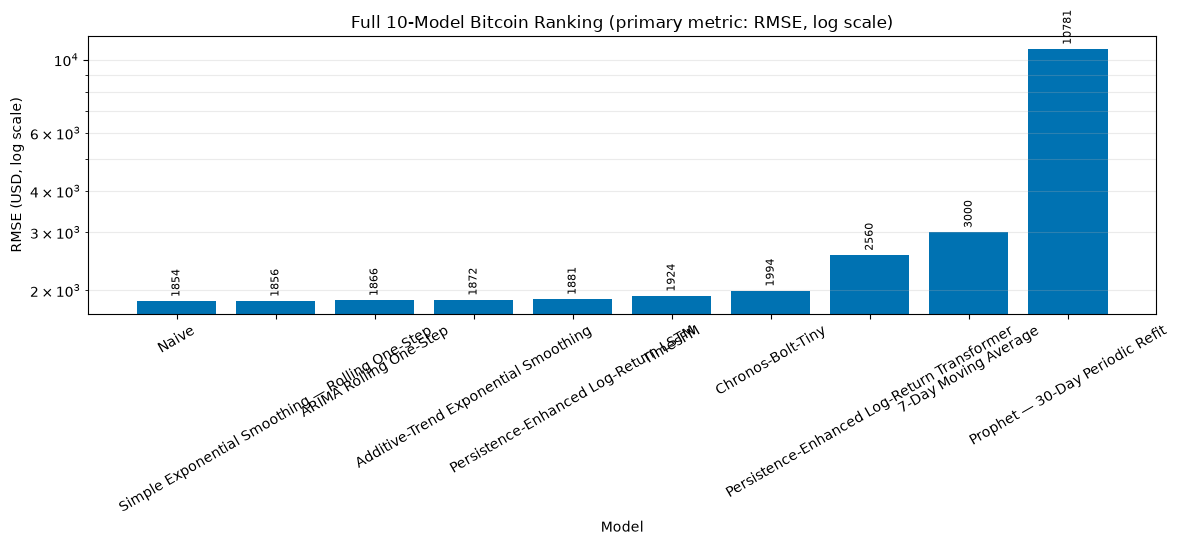

In [7]:
ranked_rmse = canonical_ranking['RMSE']
fig, ax = plt.subplots(figsize=(12, 5.5))
bars = ax.bar(ranked_rmse.index, ranked_rmse.values, color='#0072B2')
ax.bar_label(bars, fmt='%.0f', padding=3, fontsize=8, rotation=90)
ax.set_yscale('log')
ax.set(title='Full 10-Model Bitcoin Ranking (primary metric: RMSE, log scale)', xlabel='Model', ylabel='RMSE (USD, log scale)')
ax.tick_params(axis='x', rotation=30)
ax.grid(axis='y', which='both', alpha=0.25)
fig.tight_layout()
from pathlib import Path
_figure_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "figures").is_dir())
_figure_dir = _figure_root / "figures" / "bitcoin"
_figure_dir.mkdir(parents=True, exist_ok=True)
_figure_path = _figure_dir / "bitcoin_model_accuracy.png"
plt.gcf().savefig(_figure_path, dpi=300, bbox_inches="tight")
plt.show()

## 5.3 Relative Performance vs Naive

`Relative MAE = MAE_model / MAE_Naive`; `MAE Difference (%) = 100 x (Relative MAE - 1)`. Interpretation: `< 1` is an observed MAE improvement over Naive, `= 1` is Naive itself, `> 1` is an observed MAE worse than Naive. This table is the one canonical source for relative-MAE percentages in this project; small observed differences are not called statistically significant here -- that determination belongs to `11_Bitcoin_Statistical_Inference.ipynb`.

In [8]:
relative_performance = canonical_ranking[['Rank', 'MAE']].copy()
relative_performance['Relative MAE vs Naive'] = relative_performance['MAE'] / relative_performance.loc['Naive', 'MAE']
relative_performance['MAE Difference vs Naive (%)'] = 100 * (relative_performance['Relative MAE vs Naive'] - 1)
assert len(relative_performance) == 10
relative_performance.round({'MAE': 3, 'Relative MAE vs Naive': 4, 'MAE Difference vs Naive (%)': 2})

,Rank,MAE,Relative MAE vs Naive,MAE Difference vs Naive (%)
Model,,,,
Naive,1,1290.353,1.0000,0.00
Simple Exponential Smoothing — Rolling One-Step,2,1290.359,1.0000,0.00
ARIMA Rolling One-Step,3,1299.875,1.0074,0.74
Additive-Trend Exponential Smoothing,4,1308.541,1.0141,1.41
Persistence-Enhanced Log-Return LSTM,5,1321.365,1.0240,2.40
TimesFM,6,1349.947,1.0462,4.62
Chronos-Bolt-Tiny,7,1424.026,1.1036,10.36
Persistence-Enhanced Log-Return Transformer,8,2019.366,1.5650,56.50
7-Day Moving Average,9,2209.776,1.7125,71.25


# 6. Promotion Controls Reference

This notebook does not promote any artifact -- `06_Bitcoin_Foundation_Models.ipynb` contains the gated foundation-model staging/promotion logic (`RUN_GENERATION`, `PROMOTE_TO_AUTHORITATIVE`, staging under `results/staging/bitcoin/<run-id>/`, and `promote_staged_forecast`'s schema/timestamp/row-count/finite-value/hash checks).

> Notebook 06 controls where a candidate foundation-model forecast may be promoted; Notebook 07 certifies whether the resulting authoritative evidence remains structurally and numerically valid.

Any future candidate forecast promoted into the authoritative set (from Notebook 06 or any later generation notebook) must subsequently pass this freeze/validation boundary before it can be treated as part of the canonical ranking in Section 5.

# 7. Key Findings

### Validation Finding

The canonical forecast matrix passes all required integrity checks (Section 4.1): expected row count, expected schema, exact timestamp alignment, timestamp uniqueness, chronological ordering, Actual-value identity, and finiteness across every stored forecast vector. The external repository verifier (Section 4.2) completes with zero failed checks. All final target timestamps remain aligned to the canonical test index.

### Ranking Finding

From the canonical table (Section 5.1): Naive ranks first, Simple Exponential Smoothing ranks second, ARIMA Rolling One-Step ranks third, Additive-Trend Exponential Smoothing ranks fourth, the Persistence-Enhanced Log-Return LSTM ranks fifth, TimesFM ranks sixth, Chronos-Bolt-Tiny ranks seventh, the Persistence-Enhanced Log-Return Transformer ranks eighth, the 7-Day Moving Average ranks ninth, and Prophet -- 30-Day Periodic Refit ranks last (tenth), by RMSE.

> Narrower four-model or subset comparisons elsewhere in this project (e.g. Notebook 04's PE-LSTM/PE-Transformer context, Notebook 06's benchmark-floor context) do not redefine the project-wide ranking. This table is the one they must remain consistent with.

# 8. Limitations

### Internal consistency vs leakage

This notebook verifies shape, alignment, identity, completeness, ordering, and artifact consistency. It does **not** independently prove that every model was generated leakage-free. Model-specific leakage assurance is established by the model-generation notebooks themselves, their protocol documentation, `08_Bitcoin_Naive_Audit.ipynb`, and other downstream validation evidence.

### Verifier trust boundary

> The external verifier is itself trusted software within this repository; this notebook invokes it but does not independently re-derive every verification rule.

### Model-set scope

The ranking in Section 5 is authoritative for the current 10 evaluated Bitcoin models only. It is not a universal ranking of all forecasting models.

### Frozen period

The ranking applies to the current frozen Bitcoin test period (2023-08-12 to 2026-07-07) and the past-only rolling one-step / periodic-refit protocols documented in Notebooks 02-06.

# 9. Next Notebook

Next: `08_Bitcoin_Naive_Audit.ipynb`

Notebook 08 independently audits the strongest and simplest benchmark, Naive persistence, to confirm that its unexpectedly strong performance (Section 5, rank 1) arises from legitimate one-step persistence rather than an indexing error or target leakage.